
# Evaluación Formativa - Modelos de Minería de Datos

## Contexto
Se analizará el rendimiento académico de estudiantes en función de distintas variables. Las respuestas a cada pregunta deben ser sustentadas con análisis y justificando el alcance de las mismas.

Variables:
- horas_estudio
- asistencia
- uso_redes
- nota_final
- aprueba


In [3]:

import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('caso_modelos_final.csv')
df.head()


,horas_estudio,asistencia,uso_redes,nota_final,aprueba
0,7,77,3,6.244140,1
1,4,51,3,4.718704,1
2,8,91,4,7.000000,1
3,5,94,6,5.967208,1
4,7,55,1,6.791433,1


## Exploración de datos

In [4]:
df.describe()

,horas_estudio,asistencia,uso_redes,nota_final,aprueba
count,120.000000,120.000000,120.000000,120.000000,120.000000
mean,5.250000,73.950000,3.900000,5.783104,0.866667
std,2.567574,14.997955,1.997477,1.286107,0.341360
min,1.000000,50.000000,1.000000,2.480640,0.000000
25%,3.000000,60.000000,2.000000,4.692704,1.000000
50%,5.000000,76.000000,4.000000,6.241403,1.000000
75%,7.250000,86.000000,6.000000,7.000000,1.000000
max,9.000000,99.000000,7.000000,7.000000,1.000000


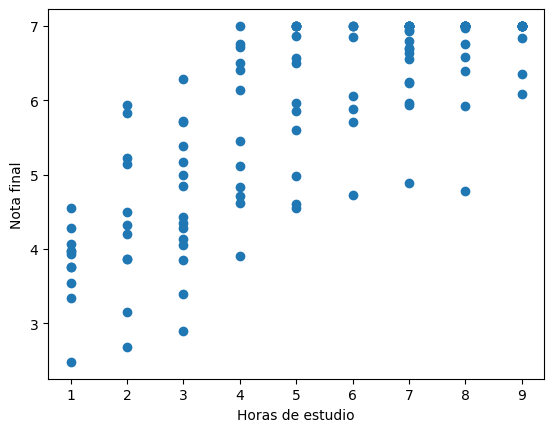

In [5]:

plt.scatter(df['horas_estudio'], df['nota_final'])
plt.xlabel("Horas de estudio")
plt.ylabel("Nota final")
plt.show()



### Preguntas
- ¿Qué tipo de relación observas?

Se puede observar una relacion positiva entre `horas_estudio` y `nota_final`. Lo que quiere decir que a medida que aumentas las horas de estudio, tienden a tener mejor nota final. Pero tambien hay otras variables que podrian influir como la `asistencia` o `uso_redes`
- ¿Qué variable parece tener mayor impacto?

La variable que al parecer tiene mayor impacto seria `horas_estudio`.

## Modelo 1: Regresión Lineal

In [6]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X = df[['horas_estudio','asistencia','uso_redes']]
y = df['nota_final']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

model = LinearRegression()
model.fit(X_train,y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)

mse, r2


(0.41518854071300787, 0.5970165972229928)


### Preguntas
- ¿Qué indica el MSE?

El MSE mide el promedio de los errores. La diferencia entre el valor real y el valor predicho por el modelo.

- ¿Cómo interpretas R²?

El $R^2$ es 0.59, quiere decir que el 59% de la nota de un alumno se puede deber a hábitos de estudio y asistencia, mientras que el 41% restante depende de factores no medidos (suerte, dificultad del examen, etc.).

## Modelo 2: Naive Bayes

In [7]:

from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_class = df['aprueba']

X_train, X_test, y_train, y_test = train_test_split(X,y_class,test_size=0.2)

nb_model = GaussianNB()
nb_model.fit(X_train,y_train)

y_pred = nb_model.predict(X_test)

accuracy = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)

accuracy, precision, recall, f1


(0.9166666666666666, 0.9047619047619048, 1.0, 0.95)


### Preguntas
- ¿Qué mide accuracy?

Mide la cantidad de predicciones correctas.

- ¿Qué diferencia hay entre precision y recall?

La precision se enfoca en la calidad de la prediccion positiva (Evita los falsos positivos), mientras que recall se enfoca en la capacidad del modelo (Evita los falsos negativos)


## Modelo 3: Árbol de Decisión

In [8]:

from sklearn.tree import DecisionTreeClassifier, plot_tree

tree = DecisionTreeClassifier(max_depth=3)
tree.fit(X_train,y_train)

y_pred = tree.predict(X_test)

accuracy = accuracy_score(y_test,y_pred)

accuracy


0.9166666666666666

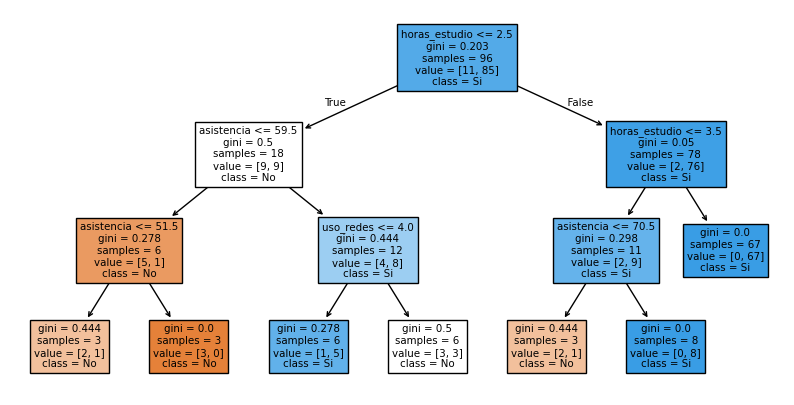

In [9]:

plt.figure(figsize=(10,5))
plot_tree(tree, feature_names=X.columns, class_names=["No","Si"], filled=True)
plt.show()



### Preguntas
- ¿Qué reglas identificas en el árbol?

Si horas_estudio < 2.5: Hay un alto riesgo de reprobar, especialmente si la asistencia es baja.

Si horas_estudio > 6: La probabilidad de aprobar es muy alta.

Si uso_redes > 6: Puede bajar la nota incluso con horas de estudio moderadas.

- ¿Qué variable aparece primero?

Aparece primero `horas_estudio`, seguida por `asistencia`


## Comparación de modelos

### Preguntas
- ¿Qué modelo entrega mejor resultado?

Para este caso creo que es mejor el modelo de **Árbol de decisión**, ya que puede capturar relaciones no lineales y "puntos de corte" especificos (como estudiar menos de 3 horas es critico).

- ¿Cuál es más fácil de interpretar?

El modelo `Árbol de decisión`, ya que visualmente es muy facil de interpretar.

- ¿En qué caso usarías cada uno?

El modelo `Regresión Lineal` lo usaria cuando necesite predecir un valor exacto (por ejemplo una nota que varia del 1 al 7).

El modelo `Naive Bayes` lo usaria cuando tengo muchas variables y necesito un modelo rapido y liviano para clasificarlas.

El modelo `Árbol de decisión` Lo usaria para entender como interactuan las variables entre si.